# MultiNest Inference Tutorial

We will learn to fit ARCADE2 data to find CMB temperature and radio excess level, our model is

\begin{equation}
T = T_{\rm{CMB}} + T_{\rm{R}} \left(\frac{\nu}{{\rm{GHz}}}\right)^\beta
\end{equation}

Import neccessary packages

In [1]:
import numpy as np
from pymultinest.solve import solve
import PyLab as PL
import time, getdist, os
from getdist import plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'text.usetex': True,
    'font.family':'Times',
    'text.latex.preamble': r'\usepackage{newtxtext,newtxmath}'})
%matplotlib inline
%load_ext autoreload
%autoreload 2
%matplotlib widget

[cangtaodeMacBook-Pro.local:38534] shmem: mmap: an error occurred while determining whether or not /var/folders/4l/x26d55ys0r77d01llftzzrfh0000gn/T//ompi.cangtaodeMacBook-Pro.501/jf.0/1152712704/sm_segment.cangtaodeMacBook-Pro.501.44b50000.0 could be created.


Information about your parameters: name, prior min and max, latex

In [2]:
infos = [
  {'name':'Tcmb', 'min':0, 'max':10, 'latex':'T_{\mathrm{cmb}}'},
  {'name':'TR', 'min':0, 'max':10, 'latex':'T_{\mathrm{R}}'},
  {'name':'Beta', 'min':-10, 'max':10, 'latex':'\\beta'}]

Define models, likelihood and prior

In [3]:
# do_mcmc = 1
FileRoot = 'data/arcade_'

ndim = len(infos)

def Get_Arcade_Data():
    # Radio tempertures from Tab.4 of ARCADE2 paper (0901.0555), beware of the differences of antenna temp and thermo temp
    Arcade_Data = {
        'Frequency_GHz': np.array([0.022, 0.045, 0.408, 1.42, 3.2, 3.41, 7.97, 8.33, 9.72, 10.49, 29.5, 31, 90]),
        'Temperature_K': np.array([21200, 4355, 16.24, 3.213, 2.792, 2.771, 2.765, 2.741, 2.732, 2.732, 2.529, 2.573, 2.706]),
        'Uncertainty_K': np.array([5125, 520, 3.4, 0.53, 0.01, 0.009, 0.014, 0.016, 0.006, 0.006, 0.155, 0.076, 0.019])}
    return Arcade_Data
Arcade_Data = Get_Arcade_Data()

def model(Tcmb, TR, Beta):
    v = Arcade_Data['Frequency_GHz']
    v0 = 1.0
    T = Tcmb + TR*(v/v0)**Beta
    return T

def Flat_Prior(theta):
    r = PL.Set_Uniform_Multinest_Prior(theta = theta, infos = infos)
    return r

def log_likelihood(theta):
    Tcmb, TR, Beta = theta
    t0 = Arcade_Data['Temperature_K']
    dt = Arcade_Data['Uncertainty_K']
    t = model(Tcmb, TR, Beta)
    Chi2 = np.sum(((t-t0)/dt)**2)
    LnL = - Chi2/2 # Missing Normalization
    # PL.SaySomething()
    # time.sleep(0.0)
    # print(LnL)
    return LnL

In [4]:
t1 = time.time()
result = solve(
    LogLikelihood = log_likelihood,
    Prior = Flat_Prior, 
	n_dims = ndim,
    outputfiles_basename = FileRoot,
    n_live_points = 100 * ndim,
    resume = False,
    verbose = True,
    n_iter_before_update = 10)
t2 = time.time()
print("Time Used: {:.2f} s".format(t2 - t1))

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  300
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.988701
Replacements:                                350
Total Samples:                               354
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):   -1284.635576 +/-  0.998587
Acceptance Rate:                        0.970874
Replacements:                                400
Total Samples:                               412
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):   -1284.787302 +/-  0.998786
Acceptance Rate:                        0.941423
Replacements:                                450
Total Samples:                               478
Nested Sampling

Print some useful info: Bayesian Evidence, parameter constraints

In [5]:
print(result['logZ'])
print(result['logZerr'])

print('evidence: %(logZ).1f +- %(logZerr).1f' % result)
print()
print('parameter values:')
parameters = ['Tcmb', 'TR', 'Beta']
for name, col in zip(parameters, result['samples'].transpose()):
    print('%15s : %.3f +- %.3f' % (name, col.mean(), col.std()))


-23.077034560729896
0.21745500963167683
evidence: -23.1 +- 0.2

parameter values:
           Tcmb : 2.730 +- 0.004
             TR : 1.203 +- 0.138
           Beta : -2.613 +- 0.043


# Post-processing

Make triangular plot and computed limits for derived params

You will need my PyLab package which does all this streamlessly

- Print param names and ranges

- Compute derived quantities

Print out free parameter infos

In [6]:
PL.print_mcmc_info(FileRoot, infos)

Triangular plot for free params

data/arcade_.txt
Removed no burn in


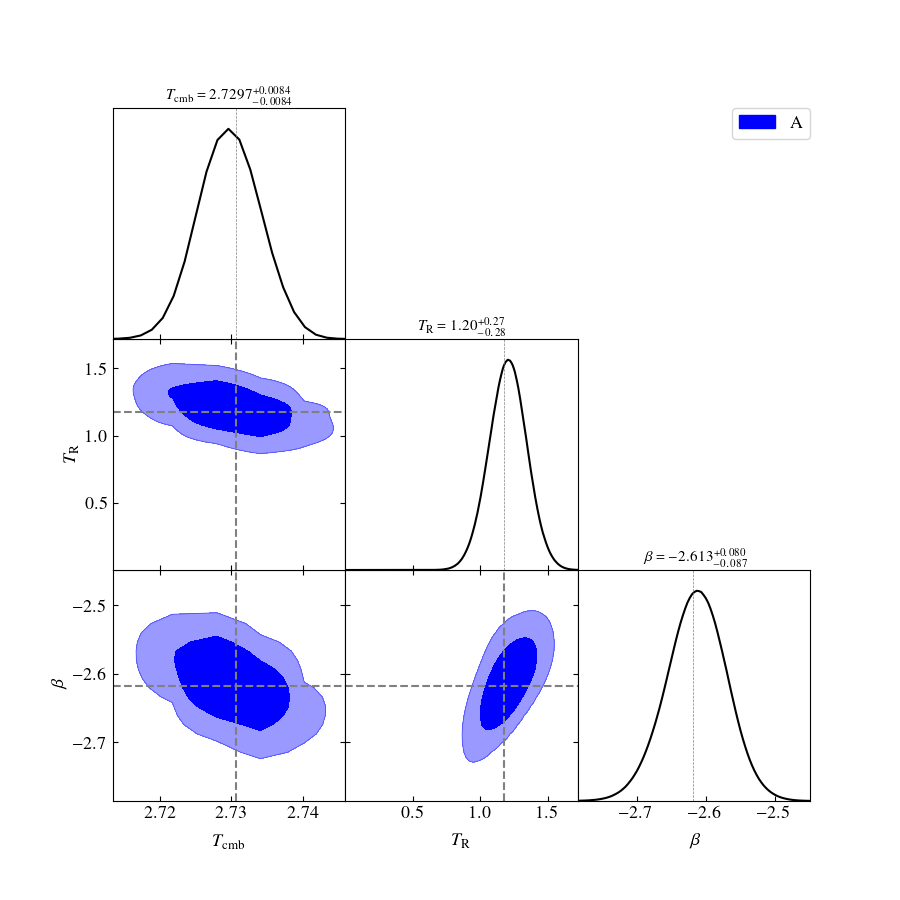

In [7]:
samples = getdist.mcsamples.loadMCSamples(FileRoot)
MAP = PL.Read_MultiNest_Stats(FileRoot)['MAP']

p = samples.getParams()
g = plots.getSubplotPlotter(subplot_size = 3)
g.settings.axes_fontsize=14
g.settings.title_limit_fontsize = 12
g.settings.lab_fontsize =14
g.settings.axes_labelsize = 14 # Size of axis label
g.settings.legend_fontsize = 14 # Legend size

g.triangle_plot(
    samples,
    # ['Tcmb','TR', 'Beta'], # select params, default uses all
    width_inch=12,
    contour_colors = ['blue'],
    legend_labels= 'Arcade',
    filled = True,
    line_args=[{'lw':1.5,'ls':'-', 'color':'k'}],
    title_limit = 2,
    # param_limits = {'fR': [4.5, 5.5], 'LX' : [39, 42], 'zcut' : [14, 20]}, # set axis limits
    markers = {
        'Tcmb' : MAP[0],
        'TR' : MAP[1],
        'Beta' : MAP[2]}, # Mark value, use best-fit for this example
    marker_args = {'lw' : 1.5}, # Marker setting, lw - LineWidth, can also set color etc
    )


Interested in radio excess level at 100 MHz? Compute derived chains and make triangular plot

In [8]:
current_directory = PL.os.getcwd()
FileRoot_full = current_directory+'/'+FileRoot # Convert relative path to absolute path

# Define relation between your param and your observable
def T_excess_model(theta):
    Tcmb, TR, Beta = theta
    v = 0.1
    v0 = 1.0
    T = TR*(v/v0)**Beta
    return T
# Generate new chains
FileRoot_new = FileRoot_full + 'Extended'
PL.derived_param_chains(
    model = T_excess_model,
    old_root = FileRoot_full,
    new_root = FileRoot_new,
    derived_names = {'name': 'Texcess', 'latex': 'T_{\mathrm{excess}} [{\mathrm{K}}]'},
    clean_up = False)


Now get triangular plot

/Users/cangtao/FileVault/Soft/PyLab/examples/MultiNest/data/arcade_Extended.txt
Removed no burn in


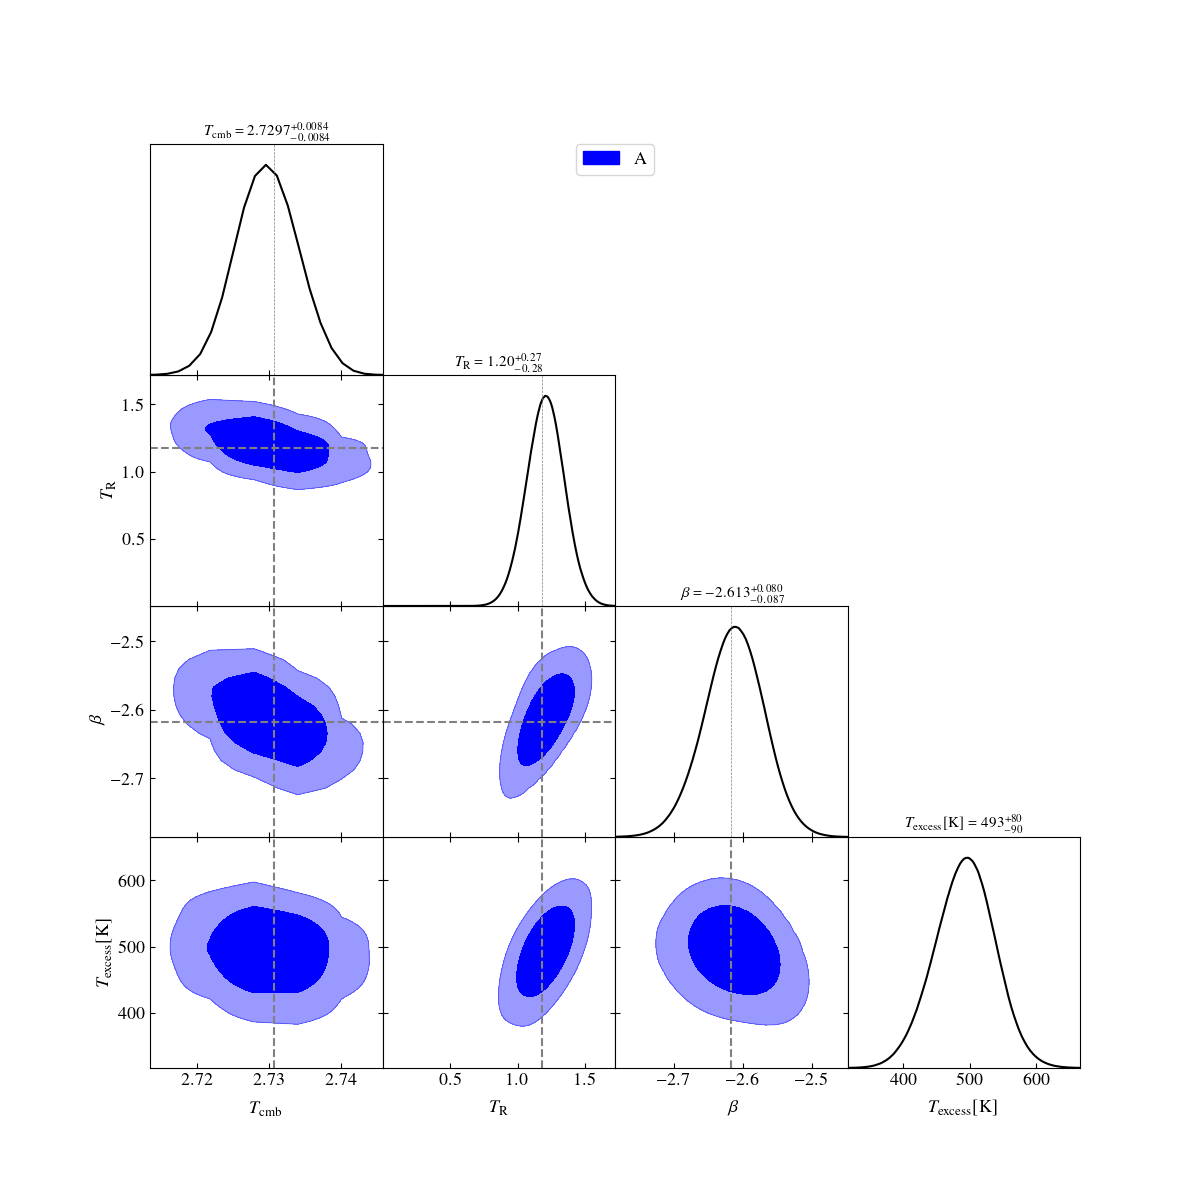

In [9]:
samples = getdist.mcsamples.loadMCSamples(FileRoot_new)

p = samples.getParams()
g = plots.getSubplotPlotter(subplot_size = 3)
g.settings.axes_fontsize=14
g.settings.title_limit_fontsize = 12
g.settings.lab_fontsize =14
g.settings.axes_labelsize = 14 # Size of axis label
g.settings.legend_fontsize = 14 # Legend size

g.triangle_plot(
    samples,
    # ['Tcmb','TR', 'Beta'], # select params, default uses all
    width_inch=12,
    contour_colors = ['blue'],
    legend_labels= 'Arcade',
    filled = True,
    line_args=[{'lw':1.5,'ls':'-', 'color':'k'}],
    title_limit = 2,
    # param_limits = {'fR': [4.5, 5.5], 'LX' : [39, 42], 'zcut' : [14, 20]}, # set axis limits
    markers = {
        'Tcmb' : MAP[0],
        'TR' : MAP[1],
        'Beta' : MAP[2]}, # Mark value, use best-fit for this example
    marker_args = {'lw' : 1.5}, # Marker setting, lw - LineWidth, can also set color etc
    )


# Advanced post-processing: $T_{\mathrm{excess}}$ at more frequencies

In [10]:
z = np.linspace(4, 30, 40)
def T_Arcade(theta):
    '''
    Arcade excess level (@v21) at z, outputs in K, see 1802.07432
    '''
    Tcmb, TR, Beta = theta
    v21 = 1.42
    v0 = v21/(1+z)
    t0 = TR * (v0**Beta) # arcade model
    t = (1+z) * t0
    return t

TA = PL.mcmc_derived_stat(
    model_function = T_Arcade,
    FileRoot = FileRoot_full,
    NewRoot = FileRoot_full + 'tmp',
    print_status = 1,
    ncpu = 12,
    remove_NaN = 1)
BestFit = PL.Read_MultiNest_Stats(Root=FileRoot_full)['MAP']
np.savez(FileRoot_full+'T_excess_posterior.npz', TA = TA, z = z)
print('Data saved to:', FileRoot+'T_excess_posterior.npz')

Computing sampels: 100%|██████████| 2960/2960 [00:01<00:00, 2881.24it/s]


Time used for derived_param_chains:  1.229461908340454
/tmp/tmp_mcmc_post_processing_swap_9.txt
/tmp/tmp_mcmc_post_processing_swap_2.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_7.txt
/tmp/tmp_mcmc_post_processing_swap_6.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_1.txt
/tmp/tmp_mcmc_post_processing_swap_4.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_5.txt
/tmp/tmp_mcmc_post_processing_swap_3.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_10.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_12.txt
/tmp/tmp_mcmc_post_processing_swap_0.txt
/tmp/tmp_mcmc_post_processing_swap_11.txt
Removed no burn in
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_8.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_13.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_16.txt
/tmp/tmp_mcmc_post_processing_swap_14.txt
/tmp/tmp_mcmc_pos

Time used for mcmc_derived_stat: 2.122387170791626
Data saved to: data/arcade_T_excess_posterior.npz


Plot distribution: 1&2 sigma of $T_{\mathrm{excess}}$ at more frequency/redshift

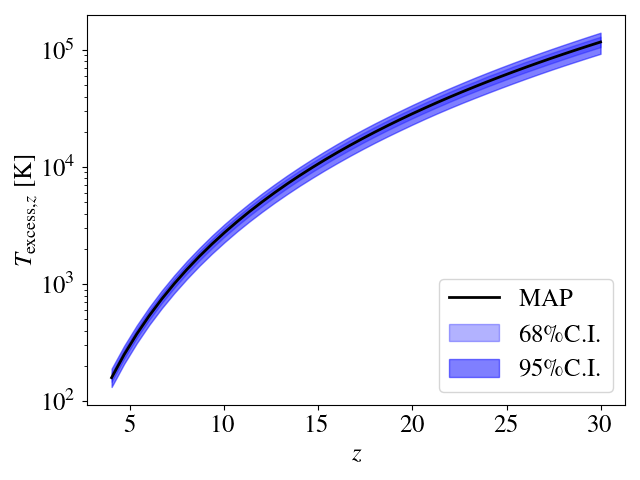

In [11]:
LineWidth = 2
FontSize = 18

d=np.load(FileRoot_full+'T_excess_posterior.npz')
z = d['z']
TA = d['TA']

plt.rcParams.update({'font.family':'Times'})
plt.rcParams['text.usetex'] = True
fig, ax = plt.subplots()
# fig.set_size_inches(8, 4)

plt.plot(z, TA[5,:], '-k', linewidth=LineWidth, label = 'MAP')
plt.fill_between(z, TA[1,:], TA[2,:], color = 'b',alpha=0.3,label='68\%C.I.')
plt.fill_between(z, TA[3,:], TA[4,:], color = 'b',alpha=0.5,label='95\%C.I.')

# plt.xscale('log')
plt.yscale('log')
plt.xlabel('$z$',fontsize=FontSize,fontname='Times New Roman')
plt.ylabel('$T_{\mathrm{excess},z}$ [K]',fontsize=FontSize,fontname='Times New Roman')
plt.xticks(size=FontSize)
plt.yticks(size=FontSize)
plt.legend(fontsize=FontSize,loc = 'lower right')
#plt.xlim([-1,7])
#plt.ylim([-1.2,1.2])
plt.tight_layout()
plt.savefig('/Users/cangtao/Desktop/tmp.pdf')


# Advanced Tutorial: Fit EDGES with a flat Gaussian

Load EDGES data

In [12]:
def Get_EDGES_Data():
    data = np.loadtxt('/Users/cangtao/FileVault/Projects/Radio_Excess_EDGES/data/Data_EDGES.txt', skiprows=1)
    freq = data[:, 0]
    wght = data[:, 1]
    tsky = data[:, 2]
    
    freq = freq[wght>0]
    tsky = tsky[wght>0]
    redshifts = 1420/freq - 1
    length = len(freq)
    EDGES_Data = {'freq':freq, 'tsky':tsky, 'redshifts':redshifts, 'length':length}
    return EDGES_Data

EDGES_Data = Get_EDGES_Data()

Models for T21 and FG

In [13]:
def Flat_Gaussian(
        a21 = 0.53,
        v0 = 78.3,
        t = 6.5,
        w = 20.7,
        v = np.linspace(50, 100, 130)):
    '''
    Flattened Gaussian T21 profile (in K)
    default params are the ones obtained in B18
    ----inputs----
    a21 : T21 amplitude in K
    v0 : central frequency in MHz
    w : FWHM
    t : flattening factor
    v: frequency in MHz
    '''
    b1 = np.log( - np.log((1 + np.exp(-t))/2)/t )
    b2 = 4*(v-v0)**2/w**2
    B = b1*b2
    t1 = 1 - np.exp( -t * np.exp(B) )
    t2 = 1 - np.exp( -t )
    t = -a21 * t1/t2
    return t

def T_FG_LinLog(linear_params, f):
    '''
    Get foreground temp in K for LinLog Model
    ---- inputs ----
    params: FG param, in [p0, p1, p2, ...]
    f: frequency in MHz
    '''
    N_FG = len(linear_params)
    f0 = 75
    index = -2.5
    t = 0
    for idx in np.arange(0, N_FG):
        t = t + linear_params[idx] * (np.log(f/f0))**(idx)
    t = t* (f/f0)**index
    return t



Define your LogLikelihood

In [14]:
def LogLike_EDGES(a21, v0, t, w, FG_params, sigmaT):
    T_cosmic = Flat_Gaussian(a21 = a21, v0 = v0, t = t, w = w, v = EDGES_Data['freq'])
    T_FG = T_FG_LinLog(linear_params = FG_params, f = EDGES_Data['freq'])
    T_sky = EDGES_Data['tsky']
    
    T_model = T_cosmic + T_FG
    Chi2_array = ((T_sky - T_model)/sigmaT)**2
    Chi2 = np.sum(Chi2_array)
    
    PreFactor = 1/np.sqrt(2 * np.pi * sigmaT**2)
    LnL_PreFactor = len(EDGES_Data['freq']) * np.log(PreFactor)
    
    LnL = -0.5 * Chi2 + LnL_PreFactor
    return LnL

Define your params and their priors

In [15]:
ParamInfos = {
        'Astro' : 
            [{'name': 'a21', 'min':0.01,'max':20.0, 'fiducial': 0.53, 'latex':'a_{21}\ [{\mathrm{K}}]'},
             {'name': 'v0', 'min':60,'max':100.0, 'fiducial': 78.3, 'latex':'\\nu_0\ [{\mathrm{MHz}}]'},
             {'name': 't', 'min':1.0,'max':15.0, 'fiducial':6.5, 'latex':'\\tau'},
             {'name': 'w', 'min':5.0,'max':40.0, 'fiducial': 20.7, 'latex':'w\ [{\mathrm{MHz}}]'}],
        'FG': 
            [{'name': 'FG1', 'min': 1000, 'max': 3000, 'latex': 'p_{\mathrm{FG,1}}'},
            {'name': 'FG2', 'min': -2000, 'max': 2000, 'latex': 'p_{\mathrm{FG,2}}'},
            {'name': 'FG3', 'min': -1000, 'max': 1000, 'latex': 'p_{\mathrm{FG,3}}'},
            {'name': 'FG4', 'min': -1000, 'max': 1000, 'latex': 'p_{\mathrm{FG,4}}'},
            {'name': 'FG5', 'min': -1000, 'max': 1000, 'latex': 'p_{\mathrm{FG,5}}'},
            {'name': 'FG6', 'min': -10000, 'max': 10000, 'latex': 'p_{\mathrm{FG,6}}'},
            {'name': 'FG7', 'min': -10000, 'max': 10000, 'latex': 'p_{\mathrm{FG,7}}'},
            {'name': 'FG8', 'min': -100000, 'max': 100000, 'latex': 'p_{\mathrm{FG,8}}'},
            {'name': 'FG9', 'min': -1000000, 'max': 1000000, 'latex': 'p_{\mathrm{FG,9}}'},
            {'name': 'FG10', 'min': -1000000, 'max': 1000000, 'latex': 'p_{\mathrm{FG,10}}'},
            {'name': 'FG11', 'min': -1000000, 'max': 1000000, 'latex': 'p_{\mathrm{FG,11}}'}],
        'Noise':
            {'name': 'swn', 'min': -4, 'max': -1, 'latex': '\log_{10} \sigma_{\mathrm{wn}}\ [{\mathrm{K}}]'}}

def Get_Param_Infos(NFG):
    infos = []
    # Astro
    for idx in np.arange(0, 4):
        infos.append(ParamInfos['Astro'][idx])
    # FG
    for idx in np.arange(0, NFG):
        infos.append(ParamInfos['FG'][idx])
    infos.append(ParamInfos['Noise'])
    return infos

def Set_FlatPrior(theta, NFG):
    infos = Get_Param_Infos(NFG = NFG)
    r = PL.Set_Uniform_Multinest_Prior(theta=theta, infos=infos)
    return r

# Run inference and post-processing

- Note: notebook does not allow MPI, to use MPI, write following modules in a .py file and run mpirun -np number_of_cpu your_script.py

In [16]:
def Run_Fit(NFG, FileRoot = '/Users/cangtao/FileVault/Soft/PyLab/examples/MultiNest/data/EDGES_FG_5_'):
    ndim = 4 + NFG + 1 # 4 for T21, NFG for FG, 1 for sigmaT
    def LogLike(theta):
        a21, v0, t, w = theta[0:4]
        FG_params = theta[4:4+NFG]
        sigmaT = 10**theta[-1]
        LnL = LogLike_EDGES(a21 = a21, v0 = v0, t = t, w = w, FG_params = FG_params, sigmaT = sigmaT)
        return LnL
    def FlatPrior(theta):
        return Set_FlatPrior(theta, NFG)
    
    # Run inference
    Start_time = time.time()
    r = solve(
        LogLikelihood = LogLike,
        Prior = FlatPrior,
        n_dims = ndim,
        n_live_points = 50 * ndim,
        resume = True,
        outputfiles_basename = FileRoot, 
        verbose = True,
        n_iter_before_update = 10)
    End_time = time.time()
    print("Run time: {:.2f} s".format(End_time - Start_time))
    
    # Post-process: find T21
    infos = Get_Param_Infos(NFG = NFG)
    PL.print_mcmc_info(FileRoot, infos)
    def Find_T21(theta):
        a21, v0, t, w = theta[0:4]
        T21 = Flat_Gaussian(a21 = a21, v0 = v0, t = t, w = w, v = EDGES_Data['freq'])
        return T21

    T21 = PL.mcmc_derived_stat(
        model_function = Find_T21,
        FileRoot = FileRoot,
        NewRoot = FileRoot + 'tmp',
        print_status = 1,
        ncpu = 12,
        remove_NaN = 1)
    np.savez(FileRoot+'T21.npz', T21 = T21, f = EDGES_Data['freq'], z = 1421/EDGES_Data['freq'] - 1)
    LnZ = r['logZ']
    print("Log-Evidence for your model: {:.2f}".format(LnZ))

    return LnZ


An example with 5 FG terms

In [ ]:
Root = '/Users/cangtao/FileVault/Soft/PyLab/examples/MultiNest/data/EDGES_FG_5_'
NFG = 5
Run_Fit(NFG = NFG, FileRoot = Root)


 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  500
 dimensionality =   10
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.996377
Replacements:                                550
Total Samples:                               552
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z): ************** +/-  0.999094
Acceptance Rate:                        0.988468
Replacements:                                600
Total Samples:                               607
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z): ************** +/-  0.999176
Acceptance Rate:                        0.967262
Replacements:                                650


Computing sampels: 100%|██████████| 16436/16436 [00:00<00:00, 79450.47it/s]


Time used for derived_param_chains:  1.5576503276824951
/tmp/tmp_mcmc_post_processing_swap_2.txt
/tmp/tmp_mcmc_post_processing_swap_0.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_4.txt
/tmp/tmp_mcmc_post_processing_swap_3.txt
/tmp/tmp_mcmc_post_processing_swap_1.txt
/tmp/tmp_mcmc_post_processing_swap_6.txt
/tmp/tmp_mcmc_post_processing_swap_5.txt
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_8.txt
/tmp/tmp_mcmc_post_processing_swap_7.txt
/tmp/tmp_mcmc_post_processing_swap_9.txt
/tmp/tmp_mcmc_post_processing_swap_10.txt
/tmp/tmp_mcmc_post_processing_swap_11.txt
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


/tmp/tmp_mcmc_post_processing_swap_12.txt
/tmp/tmp_mcmc_post_processing_swap_13.txt
/tmp/tmp_mcmc_post_processing_swap_14.txt
Removed no burn in
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_18.txt
/tmp/tmp_mcmc_post_processing_swap_15.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_16.txt
/tmp/tmp_mcmc_post_processing_swap_17.txt
Removed no burn in
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_20.txt
/tmp/tmp_mcmc_post_processing_swap_19.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_21.txt
/tmp/tmp_mcmc_post_processing_swap_23.txt
/tmp/tmp_mcmc_post_processing_swap_22.txt
Removed no burn in
Removed no burn in
Removed no burn in


/tmp/tmp_mcmc_post_processing_swap_24.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_26.txt
/tmp/tmp_mcmc_post_processing_swap_25.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_28.txt
/tmp/tmp_mcmc_post_processing_swap_29.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_27.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_30.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_31.txt
/tmp/tmp_mcmc_post_processing_swap_32.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_34.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_35.txt
/tmp/tmp_mcmc_post_processing_swap_33.txt


Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_36.txt
/tmp/tmp_mcmc_post_processing_swap_37.txt
/tmp/tmp_mcmc_post_processing_swap_38.txt
Removed no burn in
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_39.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_40.txt
/tmp/tmp_mcmc_post_processing_swap_41.txt
Removed no burn in
Removed no burn in


/tmp/tmp_mcmc_post_processing_swap_42.txt
/tmp/tmp_mcmc_post_processing_swap_43.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_45.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_44.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_46.txt
/tmp/tmp_mcmc_post_processing_swap_47.txt
Removed no burn in
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_48.txt
/tmp/tmp_mcmc_post_processing_swap_49.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_50.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_53.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_51.txt
/tmp/tmp_mcmc_post_processing_swap_52.txt
Removed no burn in
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_55.txt
/tmp/tmp_mcmc_post_processing_swap_54.txt
Removed no burn in
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_56.txt
/tmp/tmp_mcmc_post_processing_swap_57.txt
Removed no burn in
/tmp/tmp_mcmc_post_processing_swap_58.txt
R

/tmp/tmp_mcmc_post_processing_swap_120.txt
/tmp/tmp_mcmc_post_processing_swap_121.txt
/tmp/tmp_mcmc_post_processing_swap_122.txt
Removed no burn in
Removed no burn in
Removed no burn in
Time used for mcmc_derived_stat: 4.962862014770508
Log-Evidence for your model: 221.65


221.64601133464785

# Plot T21

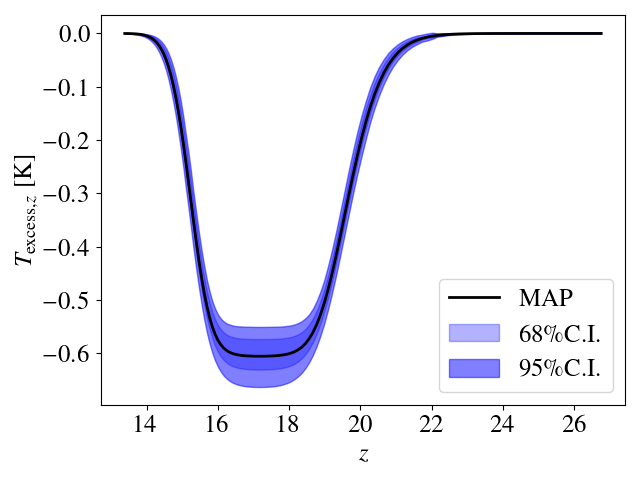

In [20]:
LineWidth = 2
FontSize = 18

d=np.load(Root + 'T21.npz')
z = d['z']
T = d['T21']

plt.rcParams.update({'font.family':'Times'})
plt.rcParams['text.usetex'] = True
fig, ax = plt.subplots()
# fig.set_size_inches(8, 4)

plt.plot(z, T[5,:], '-k', linewidth=LineWidth, label = 'MAP')
plt.fill_between(z, T[1,:], T[2,:], color = 'b',alpha=0.3,label='68\%C.I.')
plt.fill_between(z, T[3,:], T[4,:], color = 'b',alpha=0.5,label='95\%C.I.')

# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('$z$',fontsize=FontSize,fontname='Times New Roman')
plt.ylabel('$T_{\mathrm{excess},z}$ [K]',fontsize=FontSize,fontname='Times New Roman')
plt.xticks(size=FontSize)
plt.yticks(size=FontSize)
plt.legend(fontsize=FontSize,loc = 'lower right')
#plt.xlim([-1,7])
#plt.ylim([-1.2,1.2])
plt.tight_layout()
plt.savefig('/Users/cangtao/Desktop/tmp.pdf')

